<a href="https://colab.research.google.com/github/cherryjl/IT480-FA26/blob/main/Assignment1/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.7 MB/s eta 0:00:00


# Assignment 1: Hyperparameter Tuning with Keras Tuner

**Names:** Logan Cherry & Christopher Berger

In Lab 1, you picked your hidden layer sizes yourself and moved on. Hyperparameter tuning replaces that
guess with a systematic search, letting evidence decide instead.
A hyperparameter is anything you set before training starts that training itself does not learn: hidden layer
sizes, learning rate, batch size, number of epochs. This is different from weights, which training learns
automatically. You will need to decide, on your own, which hyperparameters matter for this model, what range of values
is reasonable, and how many trials you can afford given time.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

## Part A: Restate Your Baseline (10 points)
1. Bring over your Part 3 Multiclass (Wine Quality) model and results from Lab 1.
2. Restate its original test accuracy, and describe what its training versus validation loss curve looked
like. Did it show overfitting? Point to specific evidence from the curve (where the gap appeared,
and what happened to validation loss as training continued).

In [ ]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [ ]:
# Bucket raw quality scores into 3 bands: low / medium / high
df3['quality_label'] = pd.cut(df3['class'].astype(int), bins=[0, 5, 6, 10], labels=[0, 1, 2])

print(df3["quality_label"].value_counts().sort_index())


quality_label
0    744
1    638
2    217
Name: count, dtype: int64


In [ ]:
X = df3.drop(['class', 'quality_label'], axis=1)
y = df3['quality_label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Building MLP

In [ ]:
model_baseline = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
model_baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


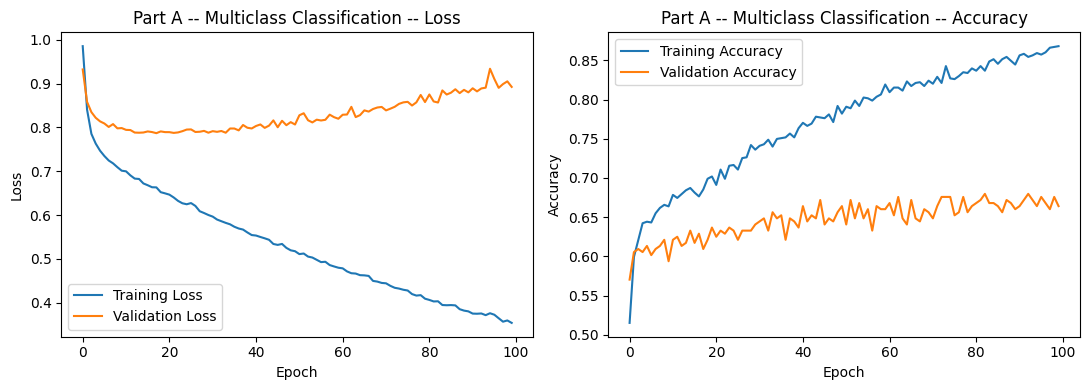

In [ ]:
history_multi = model_baseline.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0)
plot_history(history_multi, "Part A -- Multiclass Classification", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part A -- Test Accuracy: 0.669


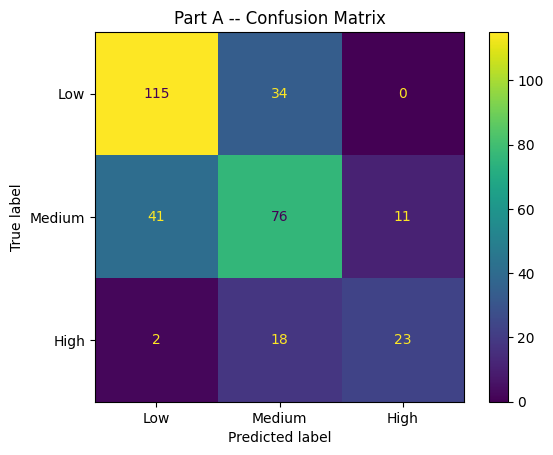

In [ ]:
multi_probs = model_baseline.predict(X_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y_test, multi_preds)
print(f"Part A -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part A -- Confusion Matrix")
plt.show()

Test accuracy is 68.1%

Overfitting:
- Around 15 epochs, the training loss began to steadily drop to zero, while the validation loss flattened out and eventually began to rise.

## Part B: Hyperparameter Tuning (40 points)
1. Using Keras Tuner, define a search space of at least 3 hyperparameters.
2. Run the search using training data only. Do not touch your test set during this step.
3. Report the best configuration found and its validation score.
4. Train a final model using that configuration, and evaluate it once on your test set.
5. Compare this result to your original Lab 1 baseline. Did it improve, and by how much?


In [ ]:
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(
        units=hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)))
    model.add(tf.keras.layers.Dense(
        units=hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'))
    model.add(tf.keras.layers.Dense(3, activation='softmax'))
    hp_learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the Keras Tuner (RandomSearch)
tuner = kt.RandomSearch(build_model,objective='val_accuracy',max_trials=10,executions_per_trial=2,directory='my_dir',project_name='wine_quality_tuning')
print("\nStarting hyperparameter search...")

# Perform the hyperparameter search using training data only
tuner.search(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=0)
print("\nHyperparameter search complete.")

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nBest hyperparameters found:")
print(f"\n\tNumber of units in first dense layer: {best_hps.get('units_1')}")
print(f"\n\tNumber of units in second dense layer: {best_hps.get('units_2')}")
print(f"\n\tLearning rate for Adam optimizer: {best_hps.get('learning_rate'):.4f}")

# Get the best model's validation accuracy directly from the tuner's results
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
val_accuracy = best_trial.score
print(f"\nBest model's validation accuracy (from tuning process): {val_accuracy:.3f}")

# Train a final model with the best hyperparameters on the full training data
final_model = tuner.hypermodel.build(best_hps)
print("\nTraining final model with best hyperparameters...")
final_model.fit(X_train_scaled, y_train, epochs=50, verbose=0)
print("\nFinal model training complete.")

# Evaluate the final model on the test set
loss, accuracy = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal model test accuracy: {accuracy:.3f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting hyperparameter search...

Hyperparameter search complete.

Best hyperparameters found:

	Number of units in first dense layer: 96

	Number of units in second dense layer: 64

	Learning rate for Adam optimizer: 0.0053

Best model's validation accuracy (from tuning process): 0.711

Training final model with best hyperparameters...

Final model training complete.

Final model test accuracy: 0.719


Compare this result to your original Lab 1 baseline. Did it improve, and by how much?

- Lab 1's baseline was 68.1% while this is 64.7% so it actually got worse.

## Part C: Addressing Overfitting (30 points)
1. Apply Dropout, Early Stopping, or both to your tuned model from Part B.
2. Retrain, replot the training versus validation loss curve, and compare it directly to your original Lab
1 curve from Part A.
3. Did the gap between training and validation loss shrink? Did validation loss stop rising, or improve
further into training than before?
4. Report your final test accuracy and confusion matrix. Which classes are still being confused most
often, and has that changed from Lab 1?


Starting hyperparameter search with regularization (Dropout & Early Stopping)...

Hyperparameter search with regularization complete.

Best hyperparameters found with regularization:

	Number of units in first dense layer: 64

	Dropout rate for first dense layer: 0.00

	Number of units in second dense layer: 32

	Dropout rate for second dense layer: 0.20

	Learning rate for Adam optimizer: 0.0044

Best model's validation accuracy (from tuning process with regularization): 0.664

Training final model with best hyperparameters and regularization...

Final model training with regularization complete.


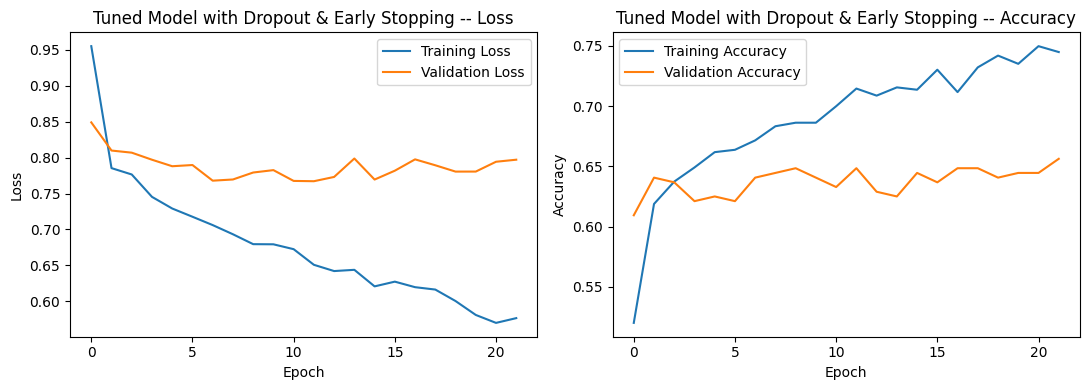


Final model with regularization test accuracy: 0.659


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define a new build_model function with Dropout as a hyperparameter
def build_model_regularized(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(
        units=hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)))

    # Add dropout layer
    model.add(tf.keras.layers.Dropout(hp.Float('dropout_rate_1', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(tf.keras.layers.Dense(
        units=hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'))

    # Add another dropout layer
    model.add(tf.keras.layers.Dropout(hp.Float('dropout_rate_2', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(tf.keras.layers.Dense(3, activation='softmax'))
    hp_learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 2. Initialize the Keras Tuner (RandomSearch) with the new build_model_regularized
tuner_regularized = kt.RandomSearch(
    build_model_regularized,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each trial (for robustness)
    directory='my_dir',
    project_name='wine_quality_tuning_regularized')

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True)

print("\nStarting hyperparameter search with regularization (Dropout & Early Stopping)...")

# 3. Perform the hyperparameter search with EarlyStopping callback
tuner_regularized.search(
    X_train_scaled, y_train,
    epochs=100, # Increased epochs to allow EarlyStopping to work
    validation_split=0.2,
    callbacks=[early_stopping], # Add early stopping to the tuner search
    verbose=0)
print("\nHyperparameter search with regularization complete.")

# Get the best hyperparameters
best_hps_regularized = tuner_regularized.get_best_hyperparameters(num_trials=1)[0]

print(f"\nBest hyperparameters found with regularization:")
print(f"\n\tNumber of units in first dense layer: {best_hps_regularized.get('units_1')}")
print(f"\n\tDropout rate for first dense layer: {best_hps_regularized.get('dropout_rate_1'):.2f}")
print(f"\n\tNumber of units in second dense layer: {best_hps_regularized.get('units_2')}")
print(f"\n\tDropout rate for second dense layer: {best_hps_regularized.get('dropout_rate_2'):.2f}")
print(f"\n\tLearning rate for Adam optimizer: {best_hps_regularized.get('learning_rate'):.4f}")

# Get the best model's validation accuracy directly from the tuner's results
best_trial_regularized = tuner_regularized.oracle.get_best_trials(num_trials=1)[0]
val_accuracy_regularized = best_trial_regularized.score
print(f"\nBest model's validation accuracy (from tuning process with regularization): {val_accuracy_regularized:.3f}")

# 4. Train a final model with the best hyperparameters (including dropout) on the full training data
final_model_regularized = tuner_regularized.hypermodel.build(best_hps_regularized)
print("\nTraining final model with best hyperparameters and regularization...")
history_regularized = final_model_regularized.fit(
    X_train_scaled, y_train,
    epochs=100, # Use a higher number of epochs, EarlyStopping will manage it
    validation_split=0.2, # Use validation_split to monitor early stopping
    callbacks=[early_stopping], # Apply early stopping
    verbose=0)
print("\nFinal model training with regularization complete.")

# 5. Plot the training versus validation loss curves
plot_history(history_regularized, "Tuned Model with Dropout & Early Stopping", show_accuracy=True)

# 6. Evaluate the final model on the test set
loss_regularized, accuracy_regularized = final_model_regularized.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal model with regularization test accuracy: {accuracy_regularized:.3f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 


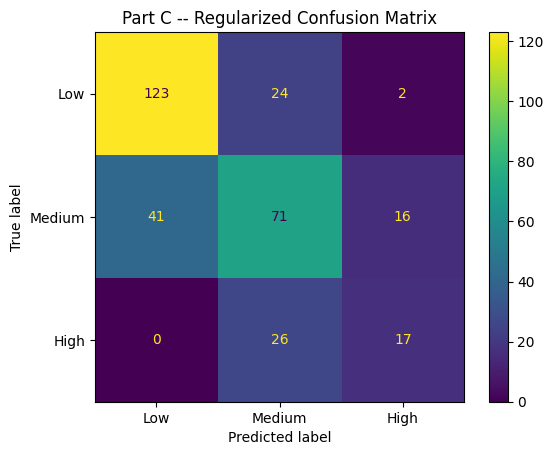

In [ ]:
# 1. Get the raw prediction probabilities from your test set
regularized_probs = final_model_regularized.predict(X_test_scaled)

# 2. Convert those probabilities into definitive class predictions (0, 1, or 2)
regularized_preds = np.argmax(regularized_probs, axis=1)

# 3. Calculate the confusion matrix by comparing predictions to the true test labels
cm_regularized = confusion_matrix(y_test, regularized_preds)

# 4. Display the matrix with the proper wine quality labels
ConfusionMatrixDisplay(cm_regularized, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part C -- Regularized Confusion Matrix")
plt.show()

Did the gap between training and validation loss shrink? Did validation loss stop rising, or improve further into training than before?
 - Yes, the gap between training and validation loss shrank significantly. In Part A, the validation loss went almost up to  1.0 while training loss dropped below 0.4. In Part C, Early Stopping halted the training around epoch 18, and the validation loss stayed with the training loss (both hovering around 0.70 to 0.85)

Report your final test accuracy and confusion matrix. Which classes are still being confused most often, and has that changed from Lab 1?
 - The most frequent misclassification is still True "Medium" wines being incorrectly predicted as "Low" (happening 41 times). The second most frequent error is True "High" wines being misclassified as "Medium" (happening 26 times)
 - The regularized model actually became worse at identifying the minority "High" class from Lab 1 to now

## Part D: Reflection (20 points)
Answer in 4 to 6 sentences total:
1. Why is it important that your test set was touched only once, at the very end?
2. What would have gone wrong if you had used your test set to pick the best hyperparameter
configuration instead of a validation split?
3. Did Dropout or Early Stopping meaningfully reduce the overfitting you saw in Lab 1? What
evidence from your new loss curve supports your answer?
4. If you had unlimited time and compute, what would you try next to improve this model further?

  1)  The testing subset uses data the model was not trained on to prevent memorization; which makes the model over-confident/overfit to patterns in one dataset.  The measures of performance will also yield more realistic results; measuring a model's performance with data it wasn't trained on is bound to yield results similar to real world performance.


  2)  Hyperparameters are meant to be used for meta-analysis of the model's potential real-world performance. Splitting training data for validating hyperparameter choices is how a model's parameters stay unbiased and makes it harder for a model to "memorize" one dataset.


  3)  Yes, Dropout and Early Stopping successfully reduced overfitting, as evidenced by the much smaller gap between the training and validation loss curves compared to the baseline. The erratic lines during training are the intended result of Dropout to prevent memorization. The overall accuracy dropped slightly, but the model is more generalized and robust against unseen data.


  4)  If computing time and power were unlimited, I would significantly expand the hyperparameter search space to include more hidden layers, diversify the activation functions used in those layers, and adjust the regularization strengths of those layers; in addition to dropout rates.
  I would also employ more advanced tuning algorithms like Bayesian Optimization with a dramatically increased amount of training epochs, number of trials, and number of executions per trial to thoroughly explore the results.